# Data Scientist Professional Practical Exam Submission

**Use this template to write up your summary for submission. Code in Python or R needs to be included.**

## 📝 Task List

Your written report should include both code, output and written text summaries of the following:
- Data Validation:   
  - Describe validation and cleaning steps for every column in the data 
- Exploratory Analysis:  
  - Include two different graphics showing single variables only to demonstrate the characteristics of data  
  - Include at least one graphic showing two or more variables to represent the relationship between features
  - Describe your findings
- Model Development
  - Include your reasons for selecting the models you use as well as a statement of the problem type
  - Code to fit the baseline and comparison models
- Model Evaluation
  - Describe the performance of the two models based on an appropriate metric
- Business Metrics
  - Define a way to compare your model performance to the business
  - Describe how your models perform using this approach
- Final summary including recommendations that the business should undertake

*Start writing report here..*

In [1]:
#KPI - achieve at least 80% prediction accuracy
#This is a binary classification problem since the outcome is categorical and only has two possible classes: high traffic and not high traffic.
#Importing packages
library(tidymodels)
library(dplyr)
library(ggplot2)
library(tidyr)
library(tidyverse)
library(xgboost)
library(ranger)
#Reading csv file and converting it into a dataframe, checking first 6 rows, and checking # rows in dataset
recipes <- read.csv("recipe_site_traffic_2212.csv")
head(recipes)
nrow(recipes)

── Attaching packages ────────────────────────────────────── tidymodels 1.2.0 ──

✔ broom        1.0.6      ✔ recipes      1.0.10
✔ dials        1.2.1      ✔ rsample      1.2.1 
✔ dplyr        1.1.4      ✔ tibble       3.2.1 
✔ ggplot2      3.5.1      ✔ tidyr        1.3.1 
✔ infer        1.0.7      ✔ tune         1.2.1 
✔ modeldata    1.3.0      ✔ workflows    1.1.4 
✔ parsnip      1.2.1      ✔ workflowsets 1.1.0 
✔ purrr        1.0.2      ✔ yardstick    1.3.1 

── Conflicts ───────────────────────────────────────── tidymodels_conflicts() ──
✖ purrr::discard() masks scales::discard()
✖ dplyr::filter()  masks stats::filter()
✖ dplyr::lag()     masks stats::lag()
✖ recipes::step()  masks stats::step()
• Use suppressPackageStartupMessages() to eliminate package startup messages

── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ forcats   1.0.0     ✔ readr     2.1.5
✔ lubridate 1.9.3     ✔ stringr   1.5.1
── Conflicts ───────────────────────────────────────

,recipe,calories,carbohydrate,sugar,protein,category,servings,high_traffic
,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<chr>,<chr>
1,1,NA,NA,NA,NA,Pork,6,High
2,2,35.48,38.56,0.66,0.92,Potato,4,High
3,3,914.28,42.68,3.09,2.88,Breakfast,1,NA
4,4,97.03,30.56,38.63,0.02,Beverages,4,High
5,5,27.05,1.85,0.80,0.53,Beverages,4,NA
6,6,691.15,3.46,1.65,53.93,One Dish Meal,2,High


[1] 947

In [2]:
#Begin data validation and cleaning
#Checking if there are duplicate rows; there are no duplicate rows
sum(duplicated(recipes))
#Ensuring datatypes in the dataset matches the datatypes in the document; servings needs to be converted to a numeric variable
str(recipes)
#Checking if servings has any non-numeric characters; there are some that need to be removed
table(recipes$servings)
#Removing non-numeric characters from servings
recipes$servings <- gsub("[^0-9.]", "", recipes$servings)
table(recipes$servings)
#Converting servings to integer
recipes$servings <- as.integer(recipes$servings)
str(recipes)

[1] 0

'data.frame':	947 obs. of  8 variables:
 $ recipe      : int  1 2 3 4 5 6 7 8 9 10 ...
 $ calories    : num  NA 35.5 914.3 97 27.1 ...
 $ carbohydrate: num  NA 38.56 42.68 30.56 1.85 ...
 $ sugar       : num  NA 0.66 3.09 38.63 0.8 ...
 $ protein     : num  NA 0.92 2.88 0.02 0.53 ...
 $ category    : chr  "Pork" "Potato" "Breakfast" "Beverages" ...
 $ servings    : chr  "6" "4" "1" "4" ...
 $ high_traffic: chr  "High" "High" NA "High" ...



           1            2            4 4 as a snack            6 6 as a snack 
         175          183          389            2          197            1 


  1   2   4   6 
175 183 391 198 

'data.frame':	947 obs. of  8 variables:
 $ recipe      : int  1 2 3 4 5 6 7 8 9 10 ...
 $ calories    : num  NA 35.5 914.3 97 27.1 ...
 $ carbohydrate: num  NA 38.56 42.68 30.56 1.85 ...
 $ sugar       : num  NA 0.66 3.09 38.63 0.8 ...
 $ protein     : num  NA 0.92 2.88 0.02 0.53 ...
 $ category    : chr  "Pork" "Potato" "Breakfast" "Beverages" ...
 $ servings    : int  6 4 1 4 4 2 4 4 6 2 ...
 $ high_traffic: chr  "High" "High" NA "High" ...


In [3]:
#Checking values for category; there is an extra category that needs to be removed, "Chicken Breast"
table(recipes$category)
head(recipes)
str(recipes)
#Combining "Chicken" with "Chicken Breast" by removing " Breast" and checking it is removed
recipes$category <- gsub(" Breast", "", recipes$category)
table(recipes$category)


     Beverages      Breakfast        Chicken Chicken Breast        Dessert 
            92            106             74             98             83 
  Lunch/Snacks           Meat  One Dish Meal           Pork         Potato 
            89             79             71             84             88 
     Vegetable 
            83 

,recipe,calories,carbohydrate,sugar,protein,category,servings,high_traffic
,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<int>,<chr>
1,1,NA,NA,NA,NA,Pork,6,High
2,2,35.48,38.56,0.66,0.92,Potato,4,High
3,3,914.28,42.68,3.09,2.88,Breakfast,1,NA
4,4,97.03,30.56,38.63,0.02,Beverages,4,High
5,5,27.05,1.85,0.80,0.53,Beverages,4,NA
6,6,691.15,3.46,1.65,53.93,One Dish Meal,2,High


'data.frame':	947 obs. of  8 variables:
 $ recipe      : int  1 2 3 4 5 6 7 8 9 10 ...
 $ calories    : num  NA 35.5 914.3 97 27.1 ...
 $ carbohydrate: num  NA 38.56 42.68 30.56 1.85 ...
 $ sugar       : num  NA 0.66 3.09 38.63 0.8 ...
 $ protein     : num  NA 0.92 2.88 0.02 0.53 ...
 $ category    : chr  "Pork" "Potato" "Breakfast" "Beverages" ...
 $ servings    : int  6 4 1 4 4 2 4 4 6 2 ...
 $ high_traffic: chr  "High" "High" NA "High" ...



    Beverages     Breakfast       Chicken       Dessert  Lunch/Snacks 
           92           106           172            83            89 
         Meat One Dish Meal          Pork        Potato     Vegetable 
           79            71            84            88            83 

In [4]:
#Checking values for high_traffic
table(recipes$high_traffic)
head(recipes)
str(recipes)
#Replacing null values with "Not high" and checking values again
recipes$high_traffic[is.na(recipes$high_traffic)] <- "Not High"
table(recipes$high_traffic)
str(recipes)


High 
 574 

,recipe,calories,carbohydrate,sugar,protein,category,servings,high_traffic
,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<int>,<chr>
1,1,NA,NA,NA,NA,Pork,6,High
2,2,35.48,38.56,0.66,0.92,Potato,4,High
3,3,914.28,42.68,3.09,2.88,Breakfast,1,NA
4,4,97.03,30.56,38.63,0.02,Beverages,4,High
5,5,27.05,1.85,0.80,0.53,Beverages,4,NA
6,6,691.15,3.46,1.65,53.93,One Dish Meal,2,High


'data.frame':	947 obs. of  8 variables:
 $ recipe      : int  1 2 3 4 5 6 7 8 9 10 ...
 $ calories    : num  NA 35.5 914.3 97 27.1 ...
 $ carbohydrate: num  NA 38.56 42.68 30.56 1.85 ...
 $ sugar       : num  NA 0.66 3.09 38.63 0.8 ...
 $ protein     : num  NA 0.92 2.88 0.02 0.53 ...
 $ category    : chr  "Pork" "Potato" "Breakfast" "Beverages" ...
 $ servings    : int  6 4 1 4 4 2 4 4 6 2 ...
 $ high_traffic: chr  "High" "High" NA "High" ...



    High Not High 
     574      373 

'data.frame':	947 obs. of  8 variables:
 $ recipe      : int  1 2 3 4 5 6 7 8 9 10 ...
 $ calories    : num  NA 35.5 914.3 97 27.1 ...
 $ carbohydrate: num  NA 38.56 42.68 30.56 1.85 ...
 $ sugar       : num  NA 0.66 3.09 38.63 0.8 ...
 $ protein     : num  NA 0.92 2.88 0.02 0.53 ...
 $ category    : chr  "Pork" "Potato" "Breakfast" "Beverages" ...
 $ servings    : int  6 4 1 4 4 2 4 4 6 2 ...
 $ high_traffic: chr  "High" "High" "Not High" "High" ...


In [5]:
#Checking if there are missing numbers for any of the columns; calories, carbohydryates, sugar, and protein are have missing numbers
colSums(is.na(recipes))
#Finding rows with missing values; there are 52 rows
recipes[!complete.cases(recipes), ]
#Removing 52 rows with missing values; they are being removed since they only make up 5.5% of all recipes and have multiple missing values
recipes <- recipes %>% drop_na()
#Ensuring the 52 columns were removed
colSums(is.na(recipes))
recipes[!complete.cases(recipes), ]
str(recipes)

recipe     calories carbohydrate        sugar      protein     category 
           0           52           52           52           52            0 
    servings high_traffic 
           0            0

,recipe,calories,carbohydrate,sugar,protein,category,servings,high_traffic
,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<int>,<chr>
1,1,NA,NA,NA,NA,Pork,6,High
24,24,NA,NA,NA,NA,Meat,2,Not High
49,49,NA,NA,NA,NA,Chicken,4,Not High
83,83,NA,NA,NA,NA,Meat,4,High
90,90,NA,NA,NA,NA,Pork,6,High
117,117,NA,NA,NA,NA,Chicken,6,High
122,122,NA,NA,NA,NA,Dessert,2,High
137,137,NA,NA,NA,NA,One Dish Meal,2,High
150,150,NA,NA,NA,NA,Potato,2,High


recipe     calories carbohydrate        sugar      protein     category 
           0            0            0            0            0            0 
    servings high_traffic 
           0            0

recipe,calories,carbohydrate,sugar,protein,category,servings,high_traffic
<int>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<int>,<chr>


'data.frame':	895 obs. of  8 variables:
 $ recipe      : int  2 3 4 5 6 7 8 9 10 11 ...
 $ calories    : num  35.5 914.3 97 27.1 691.1 ...
 $ carbohydrate: num  38.56 42.68 30.56 1.85 3.46 ...
 $ sugar       : num  0.66 3.09 38.63 0.8 1.65 ...
 $ protein     : num  0.92 2.88 0.02 0.53 53.93 ...
 $ category    : chr  "Potato" "Breakfast" "Beverages" "Beverages" ...
 $ servings    : int  4 1 4 4 2 4 4 6 2 1 ...
 $ high_traffic: chr  "High" "Not High" "High" "Not High" ...


     recipe         calories        carbohydrate         sugar        
 Min.   :  2.0   Min.   :   0.14   Min.   :  0.030   Min.   :  0.010  
 1st Qu.:237.5   1st Qu.: 110.43   1st Qu.:  8.375   1st Qu.:  1.690  
 Median :475.0   Median : 288.55   Median : 21.480   Median :  4.550  
 Mean   :473.7   Mean   : 435.94   Mean   : 35.070   Mean   :  9.047  
 3rd Qu.:708.5   3rd Qu.: 597.65   3rd Qu.: 44.965   3rd Qu.:  9.800  
 Max.   :947.0   Max.   :3633.16   Max.   :530.420   Max.   :148.750  
    protein          category            servings     high_traffic      
 Min.   :  0.000   Length:895         Min.   :1.000   Length:895        
 1st Qu.:  3.195   Class :character   1st Qu.:2.000   Class :character  
 Median : 10.800   Mode  :character   Median :4.000   Mode  :character  
 Mean   : 24.149                      Mean   :3.458                     
 3rd Qu.: 30.200                      3rd Qu.:4.000                     
 Max.   :363.360                      Max.   :6.000              

Warning message:
“There was 1 warning in `summarize()`.
ℹ In argument: `across(where(is.numeric), sd, na.rm = TRUE)`.
Caused by warning:
! The `...` argument of `across()` is deprecated as of dplyr 1.1.0.
Supply arguments directly to `.fns` through an anonymous function instead.

  # Previously
  across(a:b, mean, na.rm = TRUE)

  # Now
  across(a:b, \(x) mean(x, na.rm = TRUE))”


recipe,calories,carbohydrate,sugar,protein,servings
<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
272.7633,453.021,43.94903,14.67918,36.36974,1.735979


`stat_bin()` using `bins = 30`. Pick better value with `binwidth`.


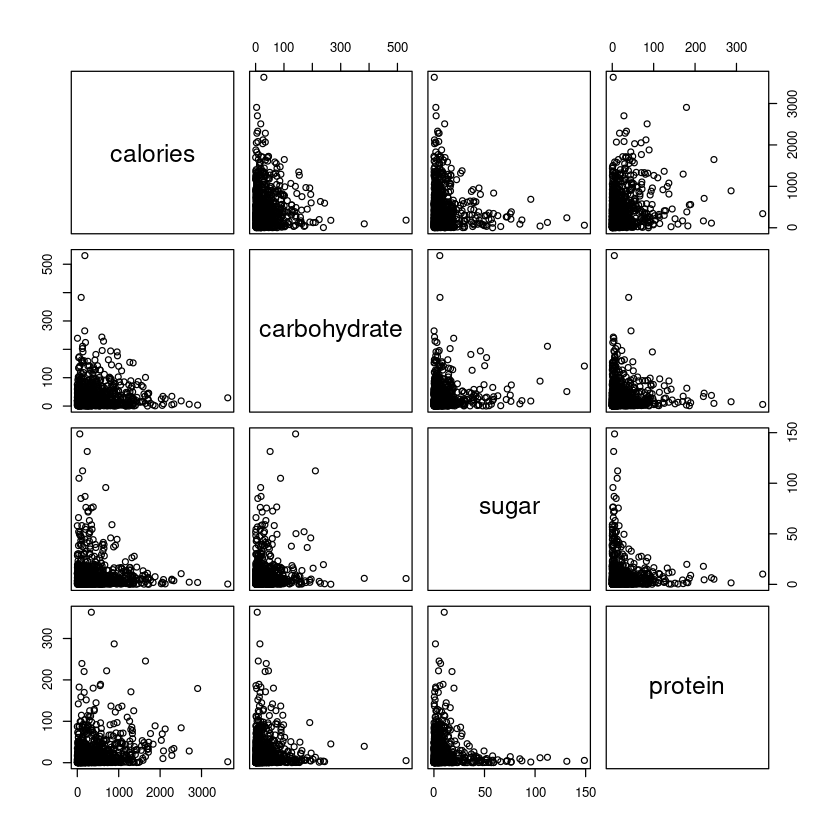

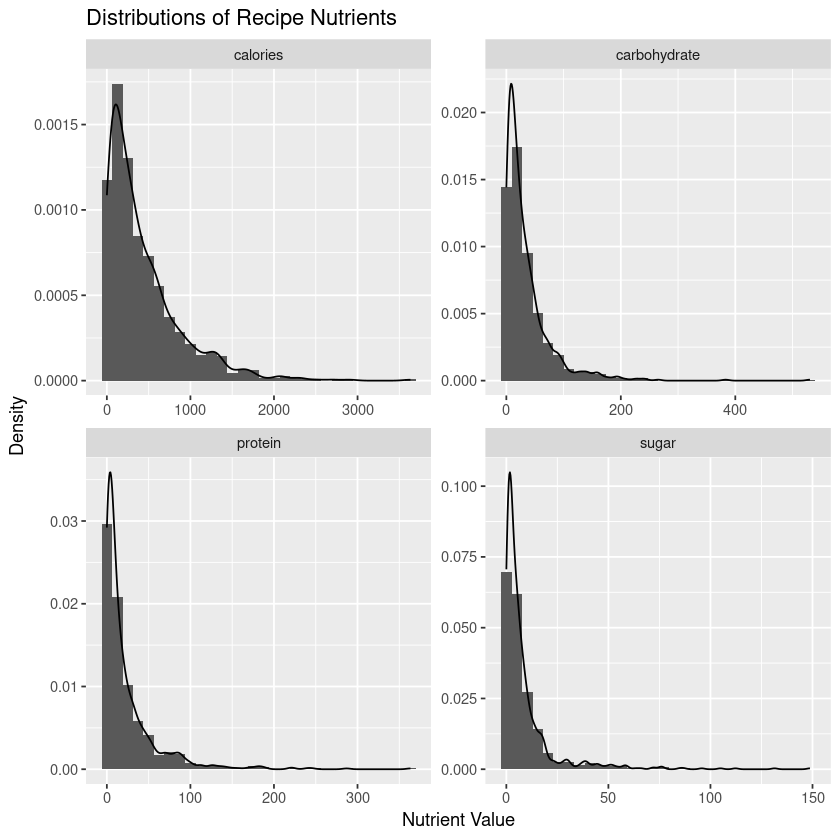

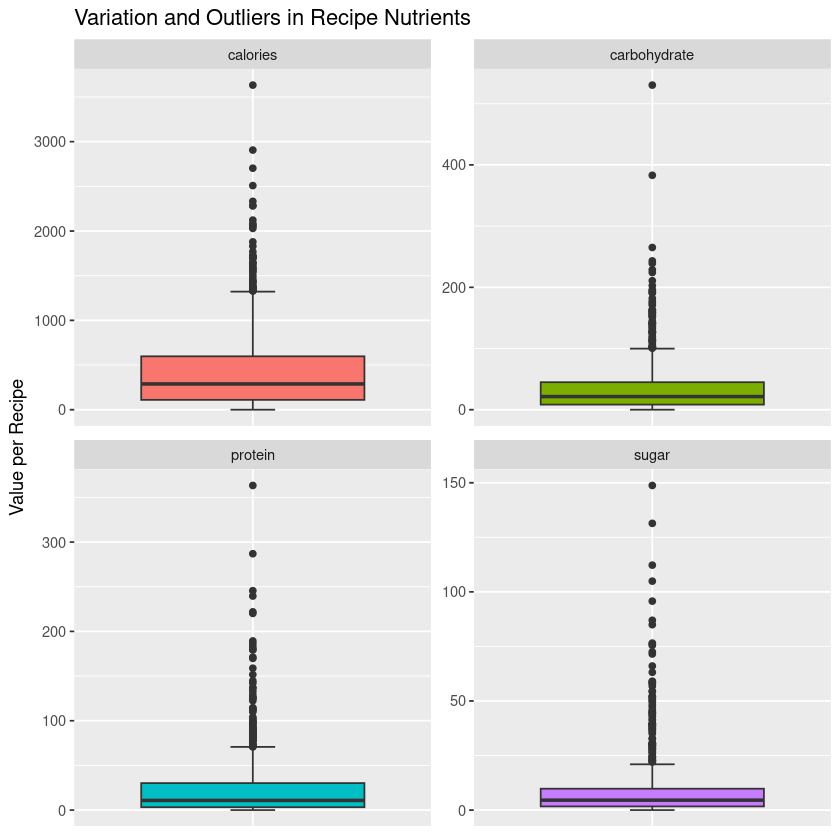

In [6]:
#Begin exploratory data analysis
#Calculating descriptive statistics; min, max, quartiles
summary(recipes)
#Calculating descriptive statistics; sd
recipes %>% summarize(across(where(is.numeric), sd, na.rm=TRUE))
#Visually checking for outliers using pairplots; there appears to be some outliers
pairs(recipes[, c("calories", "carbohydrate", "sugar", "protein")])
#Creating histograms for calories, carbohydrates, protein, and sugar (ccps); the plots show that these variables have a right-skewed distribution and are unimodal
recipes %>%
select(calories, carbohydrate, sugar, protein) %>%
pivot_longer(cols=everything(), names_to="ccps", values_to="value") %>%
ggplot(aes(value))+geom_histogram(aes(y=after_stat(density)))+geom_density()+facet_wrap(~ccps, scales = "free")+
labs(title = "Distributions of Recipe Nutrients", x = "Nutrient Value", y = "Density") 
#Plotting ccps as boxplots; the boxplots further support there are outliers for each of these variables; may revisit later
recipes %>%
select(calories, carbohydrate, sugar, protein) %>%
pivot_longer(cols=everything(), names_to="ccps", values_to="value") %>%
ggplot(aes(ccps, value, fill=ccps))+geom_boxplot(staplewidth=0.2, show.legend=FALSE) +facet_wrap(~ccps, scales="free")+
labs(title = "Variation and Outliers in Recipe Nutrients", y = "Value per Recipe")+
theme(axis.title.x = element_blank(), axis.text.x  = element_blank(), axis.ticks.x = element_blank())
#The descriptive statistics and plots suggest there may be some outliers and that the distributions for ccps are unimodal and skewed towards smaller values. The data contains outliers, so median should be used over mean since it is better at representing the typical value in a skewed distribution. 

category,median(calories),median(carbohydrate),median(protein),median(sugar)
<chr>,<dbl>,<dbl>,<dbl>,<dbl>
Beverages,126.455,11.250,0.410,8.075
Breakfast,229.380,28.420,11.685,4.830
Chicken,379.160,15.490,33.170,3.500
Dessert,288.550,38.550,4.810,24.650
Lunch/Snacks,369.505,31.985,12.965,2.750
Meat,460.870,19.115,28.530,3.385
One Dish Meal,419.280,25.430,28.480,4.040
Pork,399.260,19.560,29.820,5.230
Potato,269.460,32.540,5.900,2.640


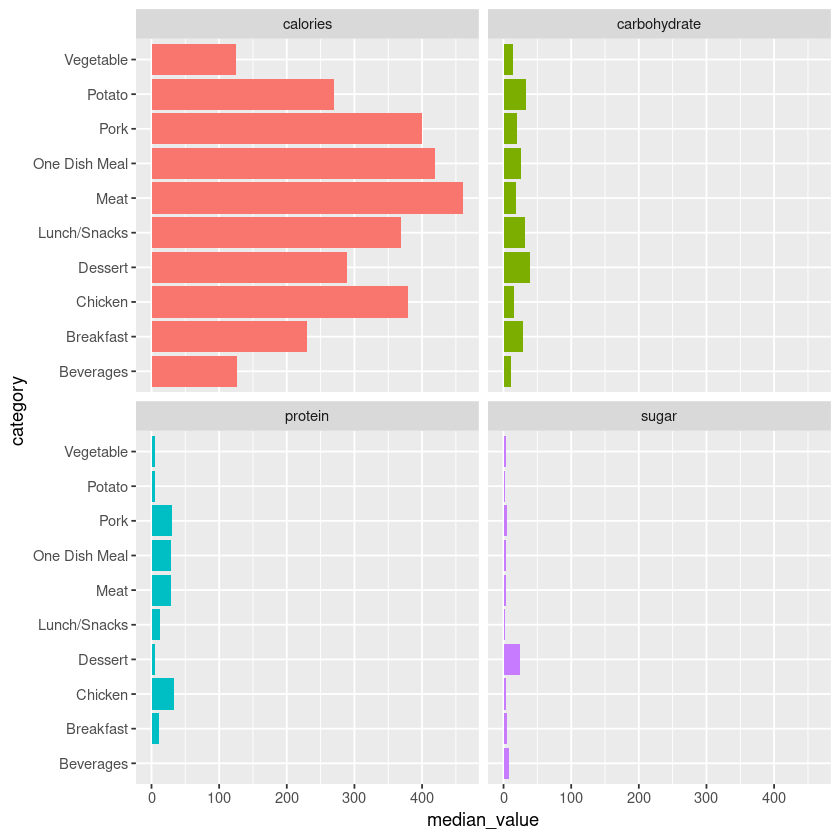

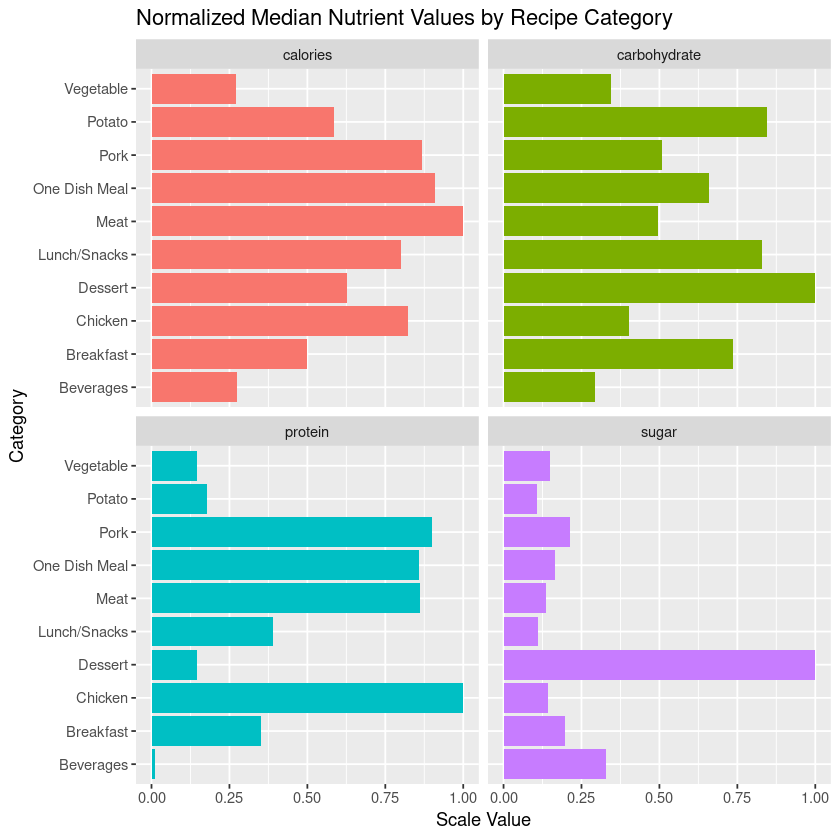

In [7]:
#Finding median ccps values for each category; as expected, ccps values vary by category
recipes %>% group_by(category) %>% 
summarize(median(calories), median(carbohydrate), median(protein), median(sugar))
#Plotting median ccps values for each category; the scales are too different so they should be normalized
medians <- recipes %>% group_by(category) %>% 
summarize(calories=median(calories), carbohydrate=median(carbohydrate), protein=median(protein), sugar=median(sugar)) %>%
pivot_longer(cols=calories:sugar, names_to="variable", values_to="median_value")
ggplot(medians, aes(category, median_value, fill=variable))+geom_col(show.legend = FALSE)+coord_flip()+facet_wrap(~variable)
#Plotting normalized median ccps values for each category; after normalization, we find that recipe categories have distinct nutritional profiles. For examples desserts are driven by sugar, meat-based dishes by protein, and vegetables and beverages having consistently low ccps values.
	#Normalizing values
medians_scaled <- medians %>% group_by(variable) %>% mutate(scaled_value=median_value/max(median_value))
	#Plotting 
ggplot(medians_scaled, aes(category, scaled_value, fill=variable))+geom_col(show.legend = FALSE)+coord_flip()+facet_wrap(~variable)+labs(title="Normalized Median Nutrient Values by Recipe Category",x="Category", y="Scale Value") 

category,total,high_traffic_count,proportion_high_traffic
<chr>,<int>,<int>,<dbl>
Beverages,92,5,0.05434783
Breakfast,106,33,0.31132075
Chicken,163,69,0.42331288
Dessert,77,48,0.62337662
Lunch/Snacks,82,52,0.63414634
Meat,74,56,0.75675676
One Dish Meal,67,51,0.76119403
Pork,73,66,0.90410959
Potato,83,78,0.93975904


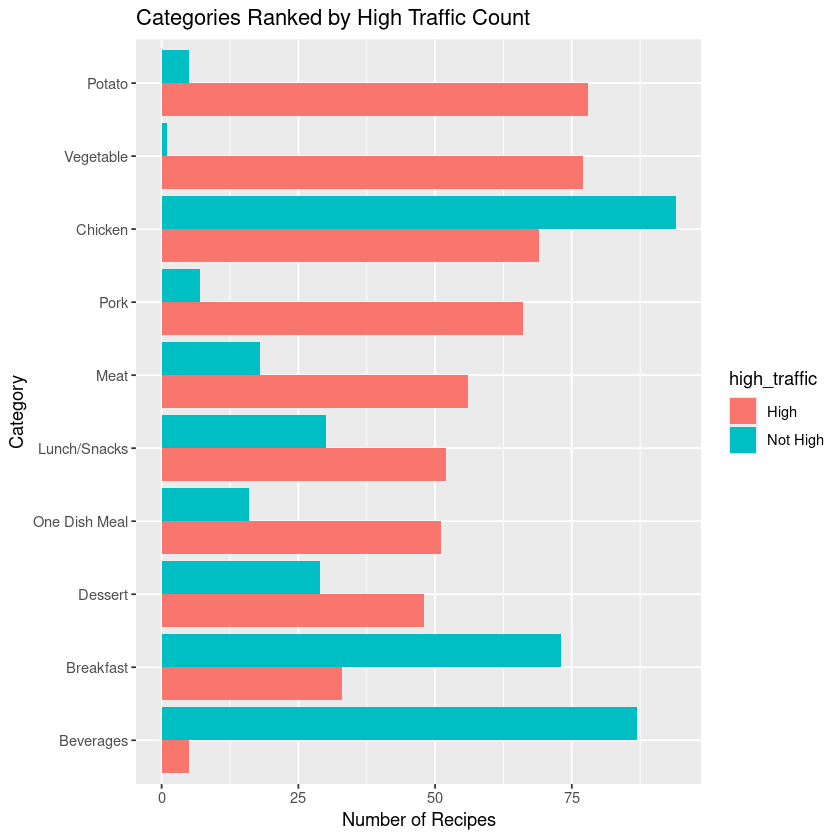

In [8]:
#Plotting relationship between serving size and high-traffic, ordered by high-traffic=High; The top five categories in high-traffic count were potato, vegetable, chicken, pork, then meat. Beverages had the lowest high-traffic count. 
recipes %>% mutate(category=fct_reorder(category, high_traffic=="High", .fun=sum)) %>%
ggplot(aes(x = category, fill=high_traffic))+
geom_bar(position = "dodge")+labs(title="Categories Ranked by High Traffic Count", x="Category", y="Number of Recipes")+coord_flip()
#Investigating proportion of high-traffic recipes for each category; The top five categories in high-traffic rate were vegetable, potato, pork, one dish meal, and meat. Beverages had the lowest high-traffic count. 
recipes %>% group_by(category) %>% summarize(total=n(), high_traffic_count = sum(high_traffic=="High"), proportion_high_traffic=high_traffic_count/total)

servings,total,high_traffic_count,proportion_high_traffic
<int>,<int>,<int>,<dbl>
1,169,99,0.5857988
2,174,98,0.5632184
4,367,220,0.5994550
6,185,118,0.6378378


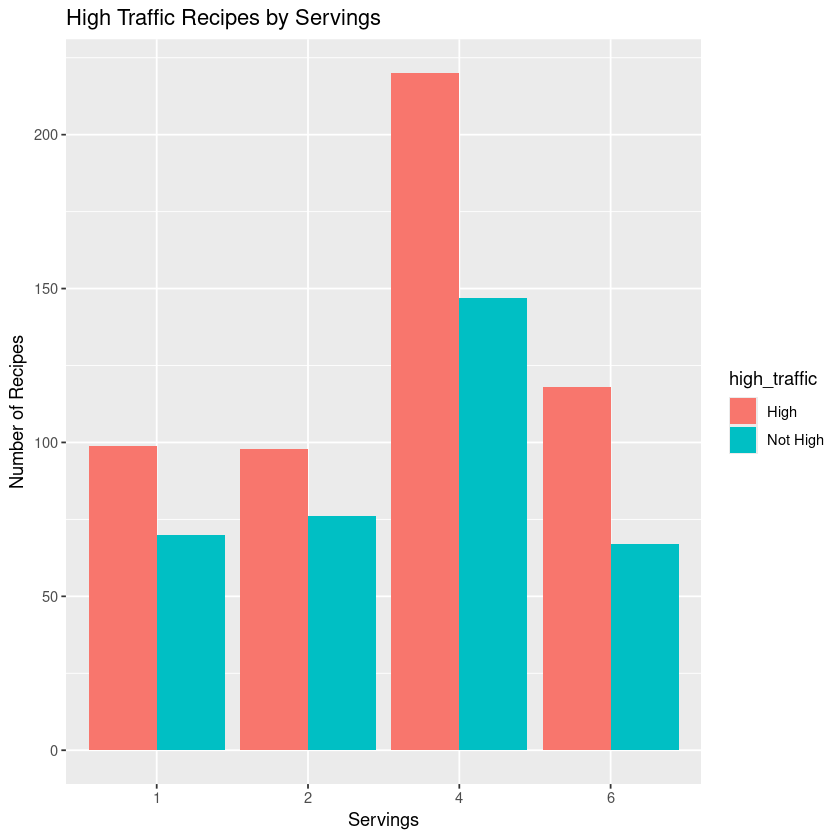

In [9]:
#Investigating relationship between serving size and high-traffic; Recipes with four servings had the highest number of high-traffic recipes, followed by six-serving, one-serving, and two-serving recipes.
ggplot(recipes, aes(factor(servings), fill = high_traffic))+geom_bar(position = "dodge")+labs(title="High Traffic Recipes by Servings", x="Servings", y="Number of Recipes") 
#Investigating proportion of high-traffic recipes for each serving size; Recipes with six servings had the highest proportion of high-traffic recipes, followed by four-serving, one-serving, and two-serving recipes.
recipes %>% group_by(servings) %>% summarize(total=n(), high_traffic_count = sum(high_traffic=="High"), proportion_high_traffic=high_traffic_count/total)

`stat_bin()` using `bins = 30`. Pick better value with `binwidth`.


high_traffic
     High  Not High 
0.5976155 0.4023845 

high_traffic
     High  Not High 
0.5982143 0.4017857 


Call:
stats::glm(formula = ..y ~ ., family = stats::binomial, data = data)

Deviance Residuals: 
    Min       1Q   Median       3Q      Max  
-2.3983  -0.8391  -0.3081   0.9043   2.5210  

Coefficients:
                        Estimate Std. Error z value Pr(>|z|)    
(Intercept)             2.102973   0.708528   2.968  0.00300 ** 
calories_log            0.018521   0.078037   0.237  0.81239    
carbohydrate_log        0.041921   0.092820   0.452  0.65153    
protein_log            -0.022447   0.098448  -0.228  0.81964    
sugar_log              -0.008871   0.109509  -0.081  0.93544    
categoryBreakfast      -1.735612   0.569722  -3.046  0.00232 ** 
categoryChicken        -2.375799   0.587582  -4.043 5.27e-05 ***
categoryDessert        -2.966075   0.575238  -5.156 2.52e-07 ***
categoryLunch/Snacks   -3.228277   0.596887  -5.409 6.35e-08 ***
categoryMeat           -3.588202   0.646503  -5.550 2.85e-08 ***
categoryOne Dish Meal  -3.661406   0.653445  -5.603 2.10e-08 ***
categoryPork   

.metric,.estimator,.estimate
<chr>,<chr>,<dbl>
roc_auc,binary,0.8365672
accuracy,binary,0.7991071


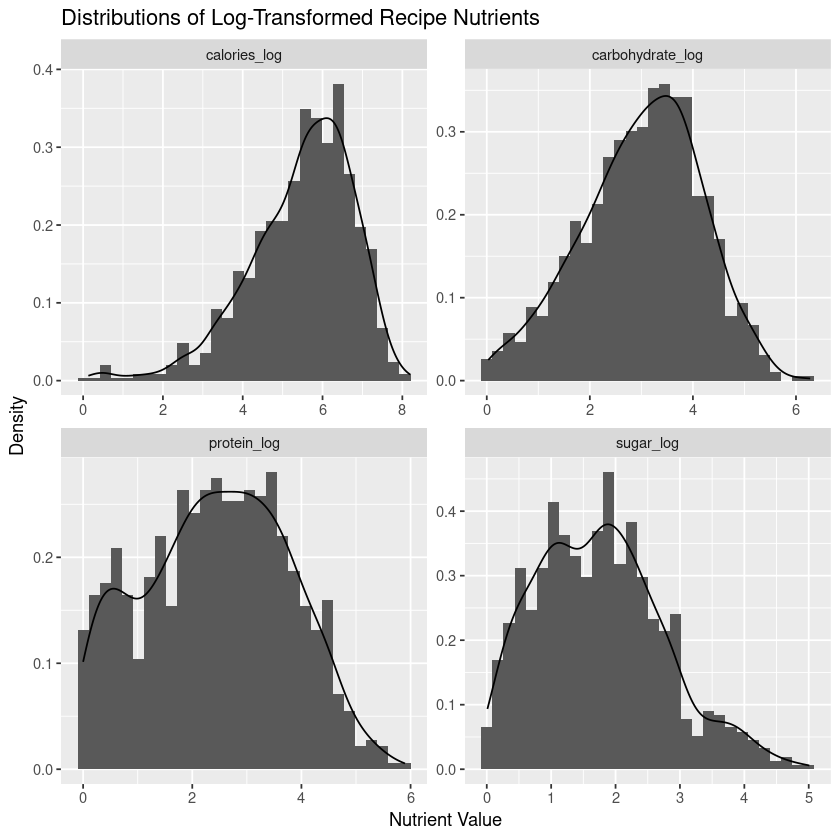

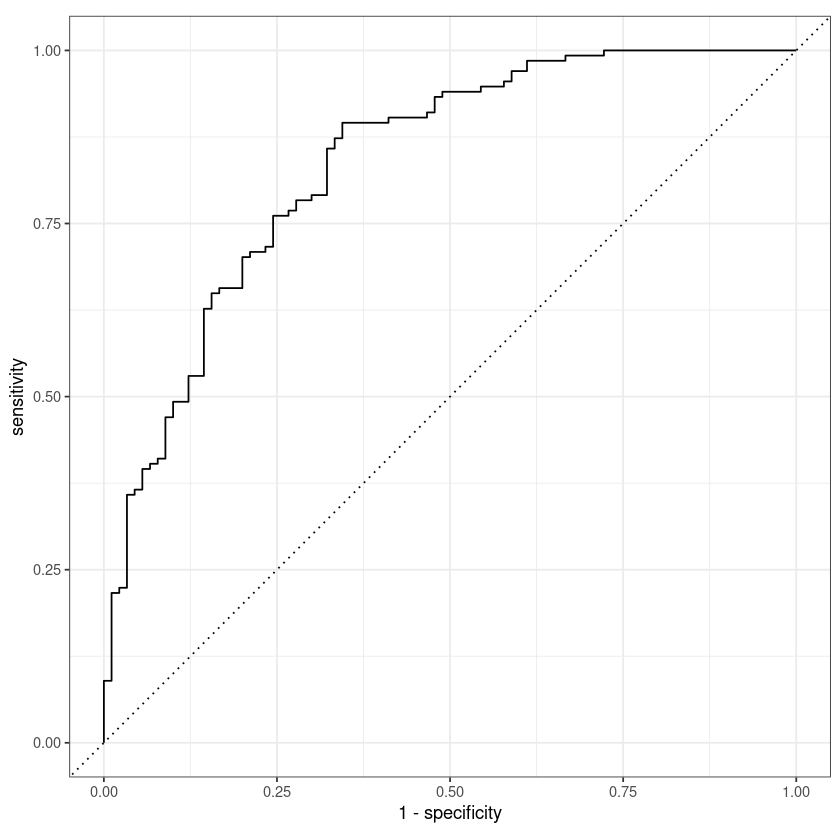

In [10]:
#Creating a tentative/baseline model using logistic regression and assessing performance; the model has a roc_auc of 0.8366 and an accuracy of 0.7991 This means 84% of the time, a randomly chosen “High traffic” recipe will have a higher predicted probability than a randomly chosen “Low traffic” recipe and 80% of recipes were correctly classified as High or Low traffic. These metrics suggest this model performs well and is reliable for selecting content that drives high traffic. 
	#Log-transforming ccps and converting category, serving, and high-traffic into categorical variables to predict high_traffic; ccps is log-transformed since they are right-skewed
ccps_transformed <- recipes %>%
mutate(calories_log=log(calories+1), carbohydrate_log=log(carbohydrate+1), protein_log=log(protein+1), sugar_log=log(sugar+1),
category=as.factor(category), servings=as.factor(servings), high_traffic=as.factor(high_traffic))
	#Plotting log ccps
ccps_transformed %>%
select(calories_log, carbohydrate_log, sugar_log, protein_log) %>%
pivot_longer(cols=everything(), names_to="ccps", values_to="value") %>%
ggplot(aes(value))+geom_histogram(aes(y=after_stat(density)))+geom_density()+facet_wrap(~ccps, scales="free")+
labs(title="Distributions of Log-Transformed Recipe Nutrients", x="Nutrient Value", y="Density") 
	#Splitting data into train and test set
set.seed(1)
split <- ccps_transformed %>% initial_split(prop=3/4, strata=high_traffic)
train <- training(split) 
test <- testing(split)
train %>% select(high_traffic) %>% table() %>% prop.table()
test %>% select(high_traffic) %>% table() %>% prop.table()
	#Declaring model
lr_model <- logistic_reg() %>% set_engine("glm")
	#Building a recipe
lr_recipe <- recipe(high_traffic ~ calories_log+carbohydrate_log+protein_log+sugar_log+category+servings, data=train)
	#Bundling into a workflow object
lr_workflow <- workflow() %>% add_model(lr_model) %>% add_recipe (lr_recipe)
	#Fitting model to the training data
lr_fit <- lr_workflow %>% fit(data=train)
	#Summarize model
lr_fit %>% extract_fit_engine() %>% summary() 
	#Assess model performance
lr_aug <- lr_fit %>% augment(test)
bind_rows(lr_aug %>% roc_auc(truth=high_traffic, .pred_High), lr_aug %>% accuracy(truth=high_traffic, .pred_class))
lr_aug %>% roc_curve(truth=high_traffic, .pred_High) %>% autoplot()

i Creating pre-processing data to finalize unknown parameter: mtry



.metric,.estimator,.estimate
<chr>,<chr>,<dbl>
roc_auc,binary,0.8071310
accuracy,binary,0.7366071


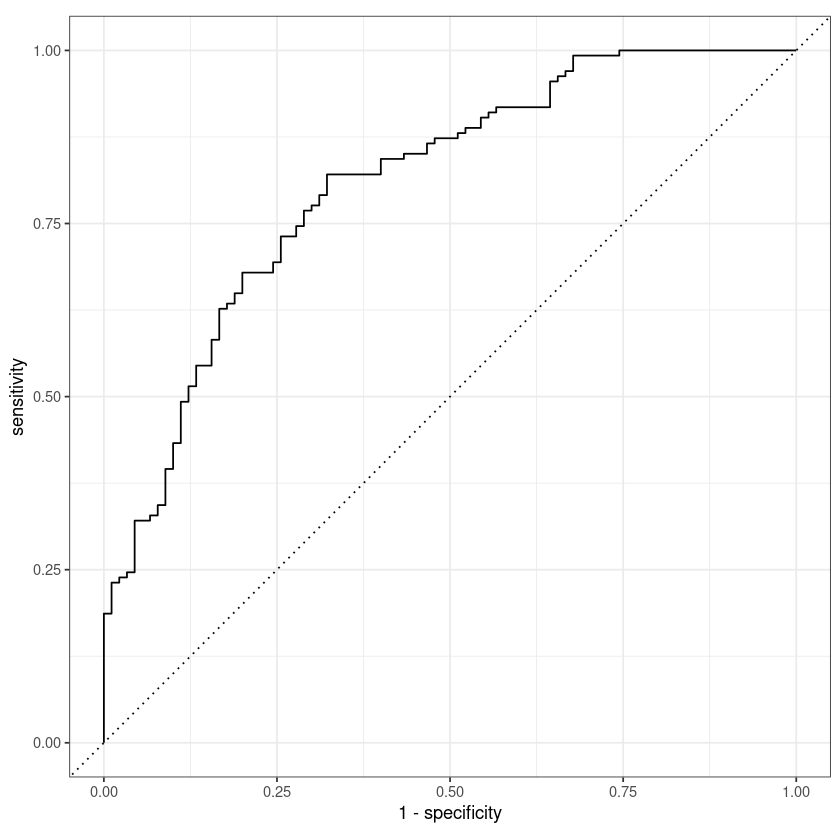

In [11]:
#Creating a comparison model using random forest and assessing performance; The model has a roc_auc of 0.8071 and an accuracy of 0.7366 This means 81% of the time, a randomly chosen “High traffic” recipe will have a higher predicted probability than a randomly chosen “Low traffic” recipe and 74% of recipes were correctly classified as High or Low traffic. These metrics suggest this model performs slightly worse than the logistic regression model but is still decent for selecting content that drives high traffic. 
	#Declaring model
rf_model <- rand_forest(mtry = tune(), trees=500, min_n=tune()) %>%
set_engine("ranger") %>% set_mode("classification")
	#Building a recipe
rf_recipe <- lr_recipe
	#Bundling into a workflow object
rf_workflow <- workflow() %>% add_model(rf_model) %>% add_recipe(rf_recipe)
	#Cross-validating 
set.seed(1)
folds <- vfold_cv(train, v=5, strata=high_traffic)
	#Tuning the random forest
rf_tuned <- rf_workflow %>% tune_grid(resamples=folds, grid=20, metrics=metric_set(roc_auc, accuracy))
	#Selecting the best model 
rf_best <- rf_tuned %>% select_best(metric="roc_auc")
	#Finalize workflow
rf_final_wf <- rf_workflow %>% finalize_workflow(rf_best)
	#Fitting model to the training data
rf_fit <- rf_final_wf %>% fit(data=train) 
	#Assess model performance
rf_aug <- rf_fit %>% augment(test)
bind_rows(rf_aug %>% roc_auc(truth=high_traffic, .pred_High), rf_aug %>% accuracy(truth=high_traffic, .pred_class))
rf_aug %>% roc_curve(truth=high_traffic, .pred_High) %>% autoplot()

## ✅ When you have finished...
-  Publish your Workspace using the option on the left
-  Check the published version of your report:
	-  Can you see everything you want us to grade?
    -  Are all the graphics visible?
-  Review the grading rubric. Have you included everything that will be graded?
-  Head back to the [Certification Dashboard](https://app.datacamp.com/certification) to submit your practical exam report and record your presentation